# Preguntas clave para tomar decisiones basadas en datos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('movies_2026.csv', encoding='latin-1')

### 9. ¿Es posible que la cantidad de hombres y mujeres en el reparto influya en la popularidad y los ingresos de las películas?

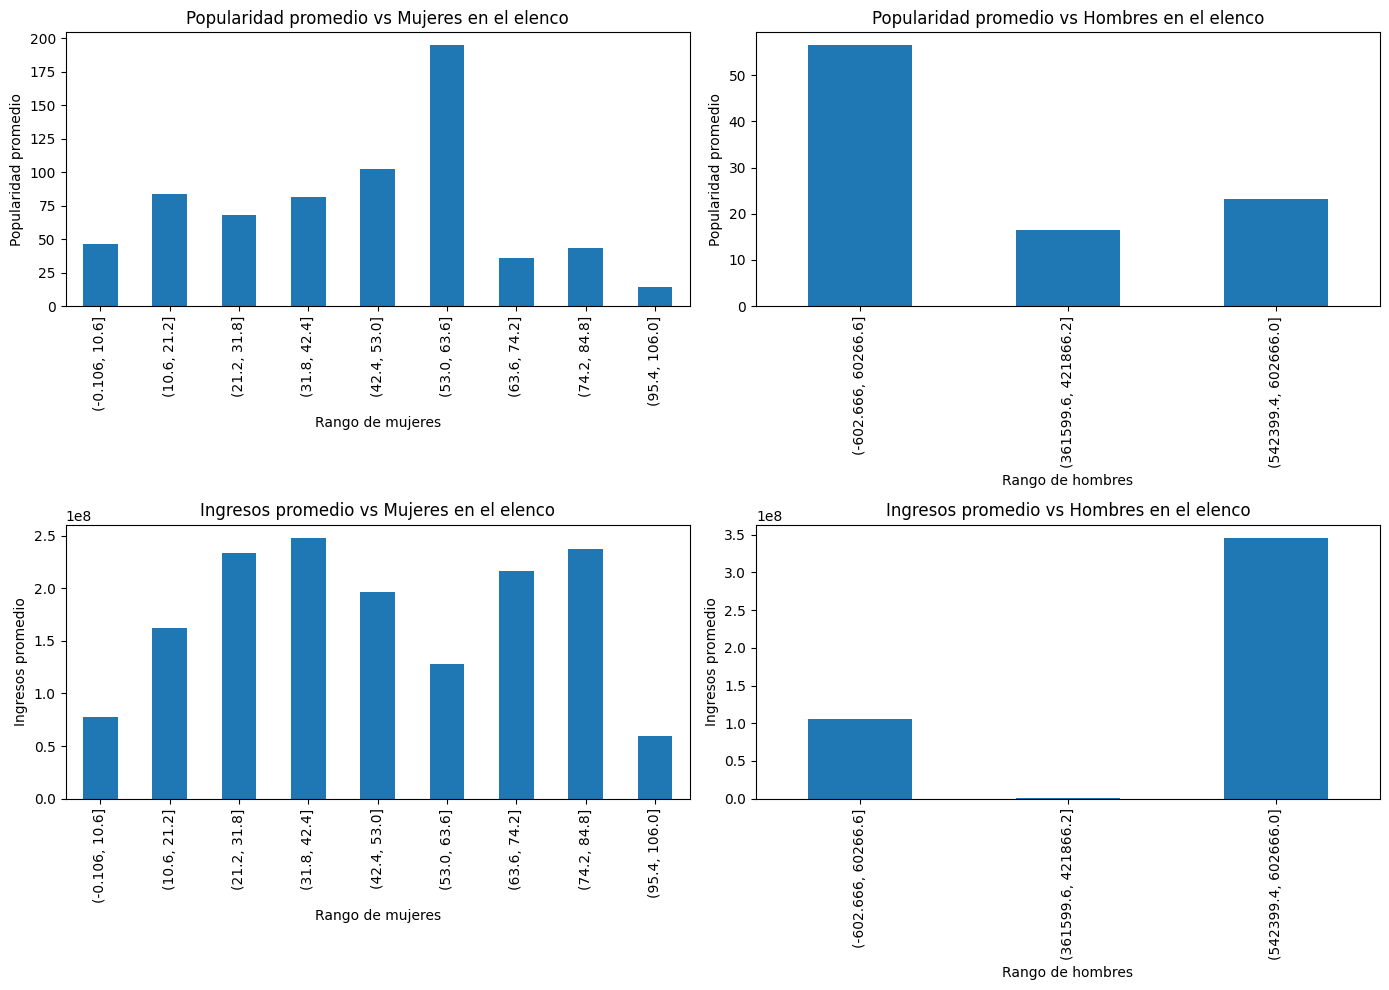

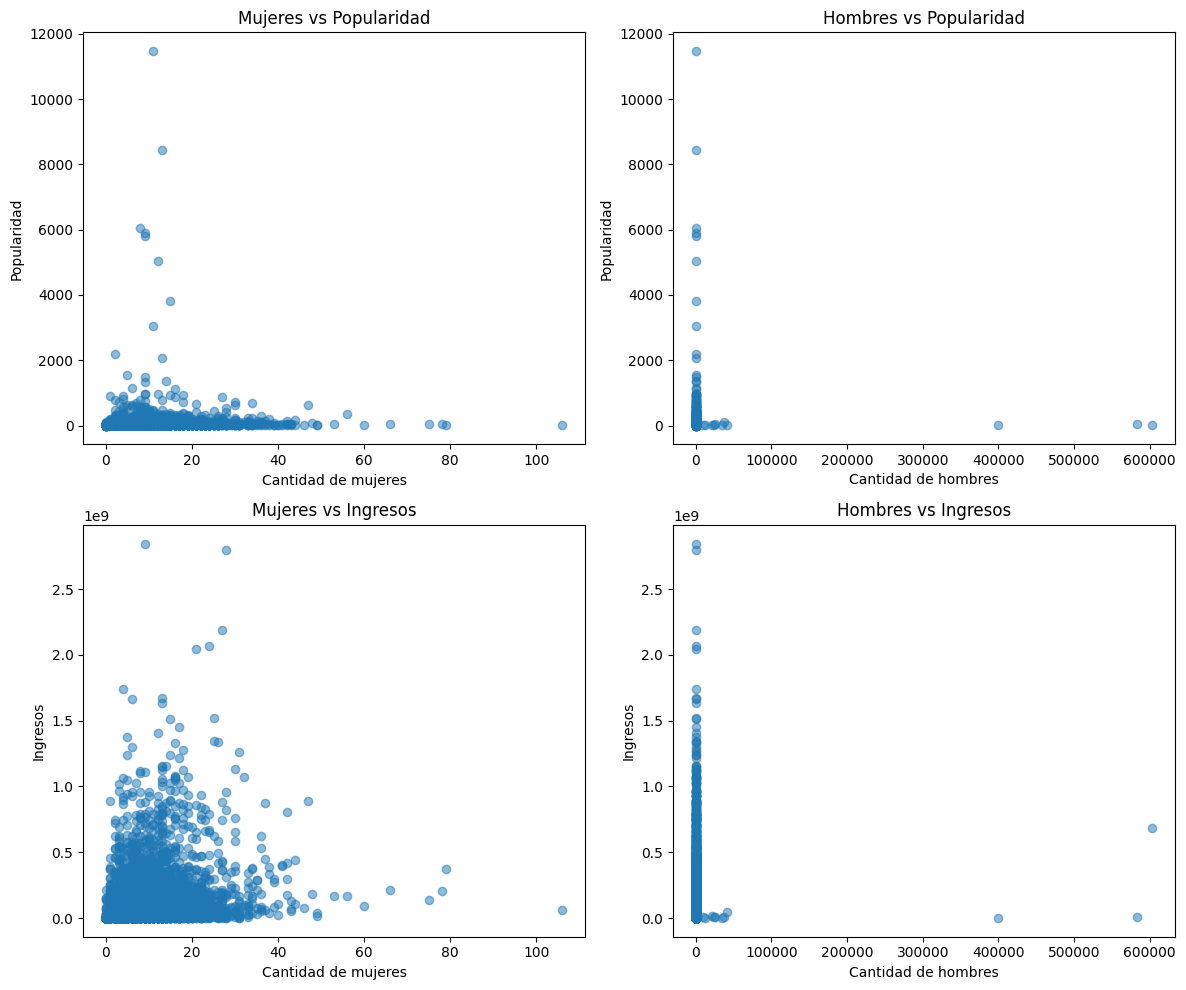

In [20]:
# castWomenAmount, castMenAmount, renvenue, popularity 

df9 = df[['castWomenAmount', 'castMenAmount', 'popularity', 'revenue']].copy()
df9 = df9.dropna()

# Eliminar películas sin ingresos reportados
df9 = df9[df9['revenue'] > 0]


bins_women = pd.cut(df9['castWomenAmount'], bins=10)
bins_men   = pd.cut(df9['castMenAmount'], bins=10)

avg_pop_women = df9.groupby(bins_women)['popularity'].mean()
avg_pop_men   = df9.groupby(bins_men)['popularity'].mean()

avg_rev_women = df9.groupby(bins_women)['revenue'].mean()
avg_rev_men   = df9.groupby(bins_men)['revenue'].mean()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mujeres vs Popularidad
avg_pop_women.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Popularidad promedio vs Mujeres en el elenco')
axes[0,0].set_xlabel('Rango de mujeres')
axes[0,0].set_ylabel('Popularidad promedio')

# Hombres vs Popularidad
avg_pop_men.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Popularidad promedio vs Hombres en el elenco')
axes[0,1].set_xlabel('Rango de hombres')
axes[0,1].set_ylabel('Popularidad promedio')

# Mujeres vs Ingresos
avg_rev_women.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Ingresos promedio vs Mujeres en el elenco')
axes[1,0].set_xlabel('Rango de mujeres')
axes[1,0].set_ylabel('Ingresos promedio')

# Hombres vs Ingresos
avg_rev_men.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Ingresos promedio vs Hombres en el elenco')
axes[1,1].set_xlabel('Rango de hombres')
axes[1,1].set_ylabel('Ingresos promedio')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Mujeres vs Popularidad
axes[0, 0].scatter(df9['castWomenAmount'], df9['popularity'], alpha=0.5)
axes[0, 0].set_title('Mujeres vs Popularidad')
axes[0, 0].set_xlabel('Cantidad de mujeres')
axes[0, 0].set_ylabel('Popularidad')

# Hombres vs Popularidad
axes[0, 1].scatter(df9['castMenAmount'], df9['popularity'], alpha=0.5)
axes[0, 1].set_title('Hombres vs Popularidad')
axes[0, 1].set_xlabel('Cantidad de hombres')
axes[0, 1].set_ylabel('Popularidad')

# Mujeres vs Ingresos
axes[1, 0].scatter(df9['castWomenAmount'], df9['revenue'], alpha=0.5)
axes[1, 0].set_title('Mujeres vs Ingresos')
axes[1, 0].set_xlabel('Cantidad de mujeres')
axes[1, 0].set_ylabel('Ingresos')

# Hombres vs Ingresos
axes[1, 1].scatter(df9['castMenAmount'], df9['revenue'], alpha=0.5)
axes[1, 1].set_title('Hombres vs Ingresos')
axes[1, 1].set_xlabel('Cantidad de hombres')
axes[1, 1].set_ylabel('Ingresos')

plt.tight_layout()
plt.show()


### Discusion de resultados
Se puede observar que existe una ligera correlación con la cantidad de mujeres en el reparto y la popularidad e ingresos de las películas. Ya que en las películas con mayor popularidad e ingresos, la cantidad de mujeres en el reparto es de mayor tamaño en comparación con las de hombres. Sin embargo, esta correlación no es muy fuerte y debido a los datos atípicos presentes en el conjunto de datos, no es posible visualizar de forma clara alguna relación viendola en un grafico de dispersión.

Sin embargo, para facilitar la interpretación de los resultados, se agruparon las películas en rangos según la cantidad de hombres y mujeres en el elenco y se calculó la popularidad e ingresos promedio por rango.

Los resultados muestran que no existe una tendencia clara que indique que un mayor número de hombres o mujeres en el reparto esté asociado con un incremento significativo en la popularidad o los ingresos de las películas. Sin embargo, si se puede notar un poco en el lado de la cantidad de mujeres en el elenco un mayor ingreso y popularidad en las películas en comparación con la cantidad de hombres en el reparto. Aun así, la diferencia no es realmente significativa y podría decirse que las películas no están influenciadas en estos aspectos

### 10. ¿Quiénes son los directores que hicieron las 20 películas mejor calificadas?




In [32]:
df10 = df[['director', 'voteAvg', 'voteCount', 'title']].copy()
df10 = df10.dropna()
# limitar a peliculas con al menos 1000 votos
df10 = df10[df10['voteCount'] >= 1000]

top_movies = df10.sort_values(by='voteAvg', ascending=False).head(20)
top_movies

# extraccion de nueva tabla con directores sin repeticiones
directores_unicos = (
    top_movies
    .sort_values(by='voteAvg', ascending=False)
    .drop_duplicates(subset='director')
    [['director', 'title', 'voteAvg']]
)

directores_unicos





,director,title,voteAvg
10049,Frank Darabont,The Shawshank Redemption,8.7
10025,Francis Ford Coppola,The Godfather,8.7
13069,Aditya Chopra,Dilwale Dulhania Le Jayenge,8.7
10107,Steven Spielberg,Schindler's List,8.6
16494,Makoto Shinkai,Your Name.,8.6
19217,Tosca Musk,Gabriel's Inferno,8.6
17807,Bong Joon-ho,Parasite,8.5
9977,Christopher Nolan,The Dark Knight,8.5
10078,Akira Kurosawa,Seven Samurai,8.5
12086,Giuseppe Tornatore,Cinema Paradiso,8.5


### Discusión de resultados 

Los directores que realizaron las top 20 mejores películas calificadas se muestran en la tabla anterior. Logramos observar que algunos directores como Francis Ford Coppola y Tosca Musk aparecen más de una vez en la lista, lo que nos puede dar a entender que estos directores tienen una buena reputación en la industria cinematográfic y que sus películas son muy bien valordas por el público y la crítica. 

Sin embargo, también realizamos otra tabla que muestra los directores sin repetición de nombres, para así también tener un mejor entendimiento de la diversidad de directores presentes que han logrado crear películas altamente calificadas. 